# Reward-Rate Matrix

Translation of `getPigeon_RRMatrix.m`

## What this notebook does

Simulates expected reward rate over a grid of decision bounds, producing a
**n_bounds × n_bounds × n_blocks** matrix for three task variants:

- **OL (blocked SNR)**: Each block contains a single SNR level. The matrix encodes
  the expected reward rate when the lo-SNR bound is `bounds[b1]` (column index) and
  the hi-SNR bound is `bounds[b2]` (row index). A single loop over bounds suffices
  because the lo and hi blocks are independent: each bound value is simulated once
  for lo-SNR and once for hi-SNR, then the results are accumulated additively.

- **MX (mixed SNR)**: Both SNR levels are interleaved within each block. The matrix
  encodes the expected reward rate when lo-SNR trials use bound `bounds[b1]` and
  hi-SNR trials use bound `bounds[b2]`. Requires a double loop because the two
  bound values jointly determine the reward rate.

- **CP (change-point)**: Each block contains a mid-trial change point at step
  `cp_step` where both the generative mean and the decision bound switch from
  pre-CP to post-CP values. The matrix encodes expected reward rate for
  (pre-CP bound, post-CP bound, CP-step) triples. The `blocks` parameter
  specifies the step positions (1-indexed, within a single trial) at which the
  change point occurs; the resulting 3rd dimension indexes these CP steps.

## Key design decisions

- **CP block defaults**: The CP simulation always uses block-2 penalty structure
  (`coins_lost = 4`), matching MATLAB's `blockDefaults(2)` selection.
- **NDT for CP**: default `ndt_min = 2`, `ndt_max = 3` → NDT ∈ {0, 1} steps,
  matching the MATLAB `getPigeon_simulatedData` convention.
- **CP step indexing**: `cp_step` is 1-indexed (MATLAB convention). `cp_step = 1`
  means all steps use post-CP parameters; `cp_step = k` means steps 1..k-1 use
  pre-CP parameters and steps k..max_steps use post-CP parameters.
- **Coin summary**: `get_coin_summary` takes the last cumulative `coin_count`
  per (subject, block), equivalent to MATLAB's `getPigeon_coinSummary` with
  `splitBySNR = false` and `useGoodTrials = false`.

## Output

Matrices are saved to the paths defined in `pigeon/pathDefaults.py`:
`RR_MATS_FILE` (CP matrices, `pmats` cell array with LowHigh and HighLow) and
`RR_MATS_OL_FILE` (OL matrix). Individual matrices can also be inspected and
plotted directly in this notebook.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.io

from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import RR_MATS_FILE as OUTPUT_FILE, RR_MATS_OL_FILE as OUTPUT_FILE_OL

## Parameters

All defaults match the MATLAB `getPigeon_RRMatrix` argument block and the actual
pigeon task generative model (see `Figure06_cpSummary.m`, lines 27–35):

- **`BOUNDS`**: bound grid `0.01 : 0.05 : 0.80` (16 values), used for both
  OL/MX and CP matrices.
- **`G_MEANS`**: generative means `[0.01, 0.02]` for lo-SNR and hi-SNR
  (SNR = g_mean / g_std = 0.2 and 0.4), matching the actual pigeon task.
- **`G_STD`**: generative SD `0.05`, matching the actual pigeon task.
- **`NUM_REPS`**: number of simulated subjects per condition (`100`).
- **`OL_BLOCKS`**: block indices `[1, 2, 3]` for the OL simulation; determines
  the 3rd dimension of the OL RR matrix.
- **`CP_STEPS_LH`** / **`CP_STEPS_HL`**: within-trial step positions at which
  the CP occurs, for LowHigh and HighLow conditions respectively. Loaded
  automatically from `boundSummaries_wCP.mat` so the matrix covers every CP step
  that appears in the real data. LowHigh and HighLow have different sets of unique
  CP steps, so separate matrices are built and saved for each condition.
- **`COMPUTE_OL`** / **`COMPUTE_MX`** / **`COMPUTE_CP`**: flags to enable
  each simulation (MX is slow — ~15 min for 16×16 grid with 100 reps; full CP
  matrices with real data CP steps take ~20 min total).

In [2]:
from pigeon.pathDefaults import BOUND_SUMMARIES_FILE

# Bound grid (matching MATLAB: 0.01:0.05:0.8)
BOUNDS    = np.arange(0.01, 0.81, 0.05)   # 16 values

# Generative model parameters — match the actual pigeon task
# (Figure06_cpSummary.m lines 27-35, and the note at the top of that file:
# "generative mean was 0.01 and 0.02 ... generative std was always 0.05")
G_MEANS   = [0.01, 0.02]   # lo-SNR and hi-SNR generative means
G_STD     = 0.05            # per-step noise SD
NUM_REPS  = 100             # simulated subjects per condition

# Block indices for OL simulation
OL_BLOCKS = [1, 2, 3]

# CP-step indices: loaded from the real data so each matrix covers exactly the
# CP steps that appear in that condition. LowHigh and HighLow have different
# sets of unique CP steps and different generative-mean orderings, so they
# require separate matrices.
_bs_mat     = scipy.io.loadmat(str(BOUND_SUMMARIES_FILE), squeeze_me=True, struct_as_record=False)
_bs         = _bs_mat['boundSummaries']
CP_STEPS_LH = np.unique(_bs.CPLowHigh).astype(int).tolist()
CP_STEPS_HL = np.unique(_bs.CPHighLow).astype(int).tolist()

# Which modes to compute (MX is slow; full CP matrices take ~20 min with 100 reps)
COMPUTE_OL = True
COMPUTE_MX = False
COMPUTE_CP = True

rng = np.random.default_rng(42)

print(f'BOUNDS ({len(BOUNDS)} values): {BOUNDS[0]:.2f} .. {BOUNDS[-1]:.2f}')
print(f'G_MEANS: {G_MEANS},  G_STD: {G_STD}')
print(f'OL blocks:       {OL_BLOCKS}')
print(f'CP steps LowHigh ({len(CP_STEPS_LH)}): {CP_STEPS_LH}')
print(f'CP steps HighLow ({len(CP_STEPS_HL)}): {CP_STEPS_HL}')

BOUNDS (16 values): 0.01 .. 0.76
G_MEANS: [0.01, 0.02],  G_STD: 0.05
OL blocks:       [1, 2, 3]
CP steps LowHigh (21): [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 26, 29, 37]
CP steps HighLow (15): [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 48]


## `get_coin_summary` helper

Translates `getPigeon_coinSummary` with `splitBySNR = false` and
`useGoodTrials = false`.

For each (subject, block) pair, returns the last cumulative `coin_count`
value (the total coins earned by the end of the block). No trial-quality
filtering is applied, matching the MATLAB default.

**Input**: DataFrame produced by `get_simulated_data_table`.

**Output**: `(n_subjects, n_blocks)` float array — total coins per
(subject, block).

In [3]:
def get_coin_summary(sim_table):
    """Return (n_subjects, n_blocks) array of total coins.

    Takes the last cumulative coin_count per (subject_index, block_index),
    equivalent to MATLAB getPigeon_coinSummary with splitBySNR=false.
    """
    subjects = np.sort(sim_table['subject_index'].dropna().unique())
    blocks   = np.sort(sim_table['block_index'].dropna().unique().astype(int))
    out      = np.full((len(subjects), len(blocks)), np.nan)

    for si, subj in enumerate(subjects):
        ls = sim_table['subject_index'] == subj
        for bi, blk in enumerate(blocks):
            lsb = ls & (sim_table['block_index'] == blk)
            if lsb.any():
                vals = sim_table.loc[lsb, 'coin_count'].dropna()
                if len(vals):
                    out[si, bi] = vals.iloc[-1]

    return out

## CP simulation helper: `_simulate_cp_mean_coins`

Simulates `num_reps` independent CP blocks and returns the mean total
coins across subjects. This is the Python equivalent of the inner loop in
MATLAB's `getPigeon_simulatedDataTable` when called with `boundType = 'cp'`.

**Key details**:

- `cp_step` is **1-indexed** (MATLAB convention). At step `cp_step`, both
  the generative mean and the bound switch from pre-CP to post-CP values:
  - Steps 1 .. cp_step − 1: `g_means[0]`, bound `pre_bound`
  - Steps cp_step .. max_steps: `g_means[1]`, bound `post_bound`
- **Block defaults**: always uses block-2 penalty structure
  (`coins_gained = 1`, `coins_lost = 4`, `steps_per_block = 600`),
  matching MATLAB's `blockDefaults(2)` used for the CP task.
- **NDT**: `ndt_min = 2`, `ndt_max = 3` → NDT ∈ {0, 1} steps, matching
  the MATLAB `getPigeon_simulatedData` default.
- **Bound crossing**: checked at each step `s = 0 .. max_steps − 1`
  (Python 0-indexed) against `bound_steps[s]`. This mirrors the MATLAB
  loop `for ss = 1:maxSteps` checking `aDV(:, ss) >= boundMatrix(:, ss)`.
- **Trial budget**: each subject's block is truncated when the cumulative
  step count reaches `steps_per_block = 600`, with the last trial aborted
  if it crosses the budget mid-trial (its coins are excluded).

In [4]:
def _simulate_cp_mean_coins(
    pre_bound, post_bound, cp_step, g_means, g_std, num_reps,
    max_steps=50, steps_per_block=600,
    coins_gained=1, coins_lost=4,
    ndt_min=2, ndt_max=3,
    rng=None,
):
    """Simulate num_reps CP blocks; return mean total coins across subjects.

    Parameters
    ----------
    pre_bound, post_bound : float
        Decision bounds before and after the change point.
    cp_step : int
        Step position (1-indexed, MATLAB convention) where the CP occurs.
    g_means : [float, float]
        Generative means [pre-CP, post-CP].
    g_std : float
        Per-step noise SD.
    num_reps : int
        Number of independent subjects to simulate.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Per-step bound and generative mean (cp_step is 1-indexed)
    # Steps 0..cp_step-2 (Python) = MATLAB steps 1..cp_step-1 → pre-CP
    # Steps cp_step-1..max_steps-1 (Python) = MATLAB steps cp_step..max_steps → post-CP
    bound_steps = np.full(max_steps, pre_bound, dtype=float)
    bound_steps[cp_step - 1:] = post_bound

    gm_steps = np.full(max_steps, g_means[0], dtype=float)
    gm_steps[cp_step - 1:] = g_means[1]

    # Over-generate trials per subject to cover the step budget
    trials_per_subj = steps_per_block // max(1, max_steps // 4) + 50
    n_total         = num_reps * trials_per_subj

    # NDTs: MATLAB randi(NDTMax-NDTMin+1) - NDTMin + 1
    ndts = rng.integers(1, ndt_max - ndt_min + 2, size=n_total) + (1 - ndt_min)

    # Generate DV with per-step generative mean
    # noise[:, s] ~ N(gm_steps[s], g_std)
    noise = rng.normal(gm_steps[None, :], g_std, size=(n_total, max_steps))
    DV    = np.concatenate(
        [np.zeros((n_total, 1)), np.cumsum(noise, axis=1)], axis=1
    )  # shape (n_total, max_steps + 1)

    # Find first crossing against per-step bound
    # crossed[:, k] = True iff |DV[:, k]| >= bound_steps[k]  (k = 0..max_steps-1)
    # This mirrors MATLAB: aDV(:, ss) >= boundMatrix(:, ss)  for ss = 1..maxSteps
    crossed = np.abs(DV[:, :max_steps]) >= bound_steps[None, :]
    any_c   = crossed.any(axis=1)
    first_k = np.argmax(crossed, axis=1)  # 0-indexed; meaningless when ~any_c

    rts     = np.full(n_total, max_steps, dtype=int)
    choices = np.full(n_total, np.nan)

    # Normal crossings (first_k > 0): MATLAB ss > 1
    normal = any_c & (first_k > 0)
    if normal.any():
        r  = np.where(normal)[0]
        k  = first_k[r]
        rts[r]     = np.minimum(k + ndts[r] + 1, max_steps)
        choices[r] = (DV[r, k] > 0).astype(float)

    # Edge case: crossing at step 0 (only when bound == 0)
    ss0 = any_c & (first_k == 0)
    if ss0.any():
        n0           = ss0.sum()
        rts[ss0]     = rng.integers(1, 3, size=n0)
        choices[ss0] = rng.integers(0, 2, size=n0).astype(float)

    # Coins per trial (NaN choice = aborted = 0 coins)
    coins_each = np.where(
        choices == 1,  float(coins_gained),
        np.where(np.isnan(choices), 0.0, float(-coins_lost))
    )

    # Accumulate per-subject totals, truncated to step budget
    subject_coins = np.empty(num_reps)
    for s in range(num_reps):
        sl    = slice(s * trials_per_subj, (s + 1) * trials_per_subj)
        cumS  = np.cumsum(rts[sl])
        cumC  = np.cumsum(coins_each[sl])

        # First trial whose cumulative steps >= budget
        idx = int(np.searchsorted(cumS, steps_per_block, side='left'))
        trial_count = min(idx + 1, trials_per_subj)

        if trial_count > 0 and cumS[trial_count - 1] > steps_per_block:
            # Last trial was aborted: exclude its coins
            subject_coins[s] = cumC[trial_count - 2] if trial_count > 1 else 0.0
        else:
            subject_coins[s] = cumC[trial_count - 1] if trial_count > 0 else 0.0

    return float(np.mean(subject_coins))

## Main function: `get_rr_matrix`

Translates the top-level `getPigeon_RRMatrix.m` function.

Returns a `(n_bounds, n_bounds, n_blocks)` array where:

- **OL**: `rr[hi_idx, lo_idx, block]` = expected coins when lo-SNR block uses
  `bounds[lo_idx]` and hi-SNR block uses `bounds[hi_idx]`. Single loop: each
  bound `b1` is used once for a lo-SNR block (populates column `b1`) and once
  for a hi-SNR block (populates row `b1`), then the results are summed.

- **MX**: `rr[hi_idx, lo_idx, block]` = expected coins when lo-SNR trials
  use `bounds[lo_idx]` and hi-SNR trials use `bounds[hi_idx]`. Double loop.

- **CP**: `rr[b1_idx, b2_idx, cp_idx]` = expected coins when the pre-CP
  bound is `bounds[b1_idx]`, the post-CP bound is `bounds[b2_idx]`, and the
  change point occurs at trial step `blocks[cp_idx]`. Double loop over bounds.
  Always call with explicit `blocks`, `g_means`, and `g_std` matching the task
  parameters; defaults are for the OL case.

**Simulation reuse (OL only)**: each bound value requires only two simulations
(lo-SNR and hi-SNR), and the per-block coin means are accumulated into the
full matrix additively — matching MATLAB's accumulation:
```
RRMatrix_(:, b1, bb) += mean(loCoinCounts(:, bb))
RRMatrix_(b1, :, bb) += mean(hiCoinCounts(:, bb))
```

In [ ]:
def get_rr_matrix(
    bounds=None,
    bound_std=0.0,
    num_reps=100,
    g_means=None,
    g_std=0.05,
    blocks=None,
    block_type='OL',
    rng=None,
):
    """Compute reward-rate matrix over a bound grid.

    Translation of getPigeon_RRMatrix.m.

    Parameters
    ----------
    bounds : array-like
        Bound grid. Default: np.arange(0.01, 0.81, 0.05) (16 values).
    bound_std : float
        Trial-to-trial SD of the bound (0 = fixed bound).
    num_reps : int
        Simulated subjects per condition.
    g_means : [float, float]
        Generative means [lo-SNR, hi-SNR].
        Default: [0.01, 0.02] — the actual pigeon task parameters.
    g_std : float
        Per-step noise SD. Default: 0.05 — the actual pigeon task parameter.
    blocks : list of int
        For OL/MX: block indices (e.g. [1, 2, 3]).
        For CP: 1-indexed within-trial step positions where the CP occurs.
                Always pass the actual unique CP steps from the data.
    block_type : {'OL', 'MX', 'CP'}
        Task variant.
    rng : np.random.Generator or None

    Returns
    -------
    np.ndarray, shape (n_bounds, n_bounds, n_blocks)
        Mean total coins per (bound_row, bound_col, block/cp_step).
        Axis semantics depend on block_type (see module docstring).
    """
    if bounds  is None: bounds  = np.arange(0.01, 0.81, 0.05)
    if g_means is None: g_means = [0.01, 0.02]
    if blocks  is None: blocks  = [1, 2, 3]
    if rng     is None: rng     = np.random.default_rng()

    bounds = np.asarray(bounds, dtype=float)
    n      = len(bounds)
    nb     = len(blocks)
    specs  = {'num_subjects': num_reps, 'blocks': blocks}
    rr     = np.zeros((n, n, nb))

    # ------------------------------------------------------------------
    if block_type.upper() == 'MX':
        # Double loop: each (lo_bound, hi_bound) pair requires its own
        # mixed-SNR simulation with per-SNR bounds.
        # b1 = lo-bound index (outer), b2 = hi-bound index (inner)
        # Store as rr[hi_idx, lo_idx, :] to match Figure05 convention.
        for b1 in range(n):
            print(f'  MX: lo-bound {b1 + 1}/{n}', end='\r')
            for b2 in range(n):
                mx_table = get_simulated_data_table(
                    specs=specs,
                    generative_mean=list(g_means),
                    bound_mean=[bounds[b1], bounds[b2]],
                    bound_std=[bound_std, bound_std],
                    correct_bias=None, rng=rng,
                )
                rr[b2, b1, :] = get_coin_summary(mx_table).mean(axis=0)
        print()

    # ------------------------------------------------------------------
    elif block_type.upper() == 'OL':
        # Single loop: lo and hi SNR blocks are independent.
        # For bound b1:
        #   lo-SNR simulation → fills column b1 (all hi-bound rows)
        #   hi-SNR simulation → fills row b1    (all lo-bound cols)
        for b1 in range(n):
            print(f'  OL: bound {b1 + 1}/{n}', end='\r')

            lo_table = get_simulated_data_table(
                specs=specs,
                generative_mean=g_means[0],
                bound_mean=bounds[b1],
                bound_std=bound_std,
                correct_bias=None, rng=rng,
            )
            lo_mean = get_coin_summary(lo_table).mean(axis=0)  # (n_blocks,)

            hi_table = get_simulated_data_table(
                specs=specs,
                generative_mean=g_means[1],
                bound_mean=bounds[b1],
                bound_std=bound_std,
                correct_bias=None, rng=rng,
            )
            hi_mean = get_coin_summary(hi_table).mean(axis=0)  # (n_blocks,)

            # Accumulate: lo bound = b1 → column b1 (all hi-rows)
            #             hi bound = b1 → row b1    (all lo-cols)
            for bb in range(nb):
                rr[:, b1, bb] += lo_mean[bb]
                rr[b1, :, bb] += hi_mean[bb]
        print()

    # ------------------------------------------------------------------
    else:  # CP
        # Double loop over (pre-CP bound, post-CP bound).
        # For each pair, simulate one block per CP step position.
        for b1 in range(n):
            print(f'  CP: pre-bound {b1 + 1}/{n}', end='\r')
            for b2 in range(n):
                for cp_idx, cp_step in enumerate(blocks):
                    rr[b1, b2, cp_idx] = _simulate_cp_mean_coins(
                        pre_bound=bounds[b1],
                        post_bound=bounds[b2],
                        cp_step=int(cp_step),
                        g_means=g_means,
                        g_std=g_std,
                        num_reps=num_reps,
                        rng=rng,
                    )
        print()

    return rr

## OL reward-rate matrix

Computes the OL (blocked-SNR) matrix and plots one heatmap per block.

Each heatmap shows expected coins as a function of (lo-SNR bound, hi-SNR
bound). Axes follow the MATLAB `imagesc` convention: x-axis = lo-SNR bound
(column index), y-axis = hi-SNR bound (row index).

**Data included**: all 16 × 16 = 256 bound pairs, 3 blocks, `NUM_REPS`
simulated subjects per condition.

Computing OL RR matrix...
  OL: bound 16/16
OL RR matrix shape: (16, 16, 3)


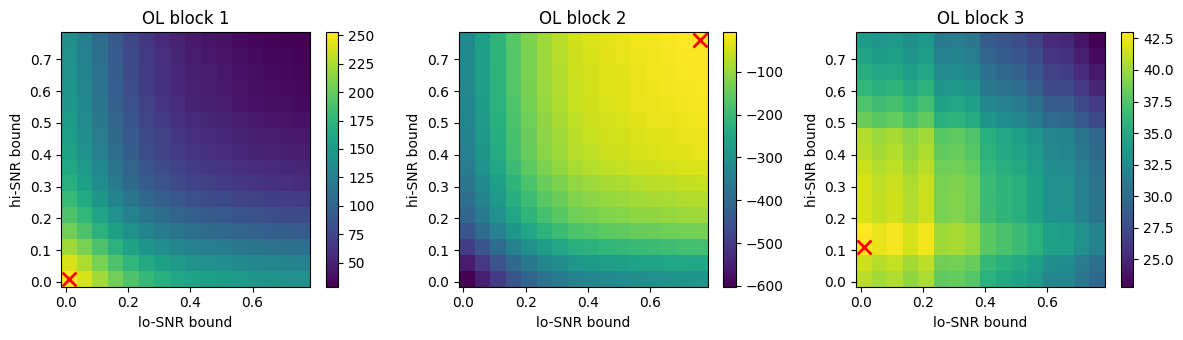

In [6]:
ol_rr = None

if COMPUTE_OL:
    print('Computing OL RR matrix...')
    ol_rr = get_rr_matrix(
        bounds=BOUNDS, num_reps=NUM_REPS,
        g_means=G_MEANS, g_std=G_STD,
        blocks=OL_BLOCKS, block_type='OL',
        rng=rng,
    )
    print(f'OL RR matrix shape: {ol_rr.shape}')

    fig, axs = plt.subplots(1, len(OL_BLOCKS), figsize=(4 * len(OL_BLOCKS), 3.5))
    b0, b1 = BOUNDS[0], BOUNDS[-1]
    for bb, (ax, blk) in enumerate(zip(axs, OL_BLOCKS)):
        im = ax.imshow(
            ol_rr[:, :, bb], origin='lower',
            extent=[b0 - 0.025, b1 + 0.025, b0 - 0.025, b1 + 0.025],
            aspect='auto', cmap='viridis',
        )
        plt.colorbar(im, ax=ax)
        opt_hi, opt_lo = np.unravel_index(ol_rr[:, :, bb].argmax(), ol_rr[:, :, bb].shape)
        ax.plot(BOUNDS[opt_lo], BOUNDS[opt_hi], 'rx', markersize=10, markeredgewidth=2)
        ax.set_xlabel('lo-SNR bound')
        ax.set_ylabel('hi-SNR bound')
        ax.set_title(f'OL block {blk}')
    plt.tight_layout()
    plt.show()

## CP reward-rate matrix

Computes the CP (change-point) matrices, one for each direction:

- **LowHigh**: `G_MEANS = [0.01, 0.02]` (SNR = 0.2 → 0.4, starts low, switches to high),
  using CP steps `CP_STEPS_LH` loaded from the real data.
- **HighLow**: `G_MEANS = [0.02, 0.01]` (SNR = 0.4 → 0.2, starts high, switches to low),
  using CP steps `CP_STEPS_HL` loaded from the real data.

Each cell `(b1, b2, cp_idx)` gives the mean coins when the pre-CP bound is
`BOUNDS[b1]`, the post-CP bound is `BOUNDS[b2]`, and the CP occurs at step
`CP_STEPS_LH[cp_idx]` (or `CP_STEPS_HL[cp_idx]` for HighLow).

The two conditions have different sets of unique CP steps in the real data
(LowHigh: 21 values, HighLow: 15 values), so they produce matrices with
different 3rd-dimension sizes. Separate `cp_steps_lh` / `cp_steps_hl` arrays
are saved so Figure06 can do exact per-subject CP-step lookups.

**Performance**: `16 × 16 × (len(CP_STEPS_LH) + len(CP_STEPS_HL))` simulation
calls total (~20 min with `NUM_REPS = 100`). Heatmaps show 5 evenly-spaced
CP-step slices from each matrix for inspection.

Computing CP RR matrix (LowHigh, 21 CP steps × 16×16 bounds)...
  CP: pre-bound 16/16
LowHigh CP RR matrix shape: (16, 16, 21)
Computing CP RR matrix (HighLow, 15 CP steps × 16×16 bounds)...
  CP: pre-bound 16/16
HighLow CP RR matrix shape: (16, 16, 15)


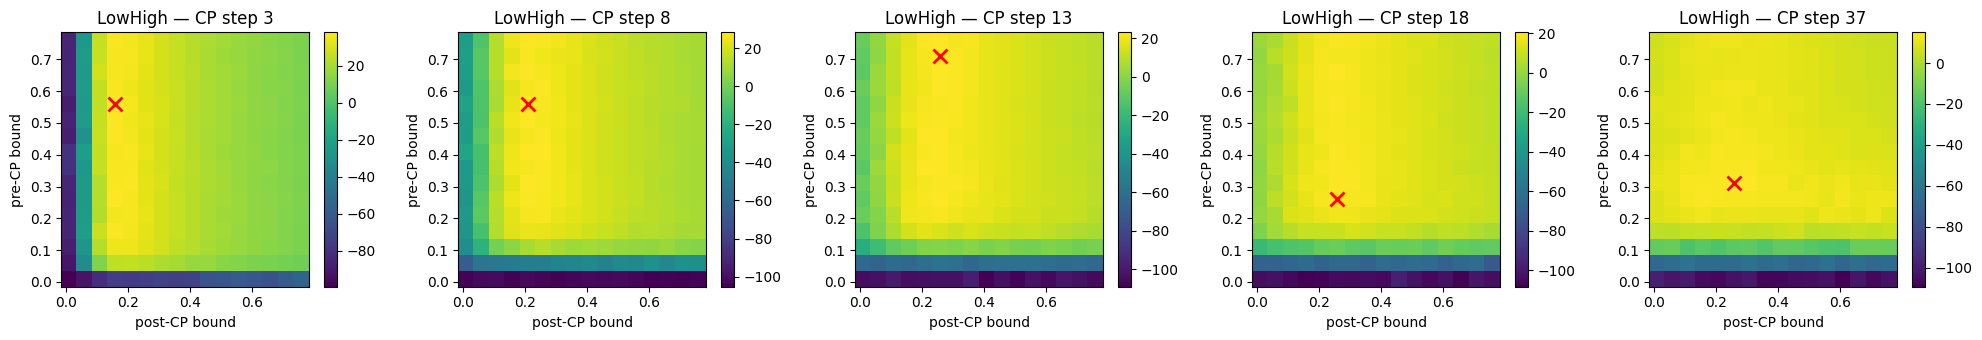

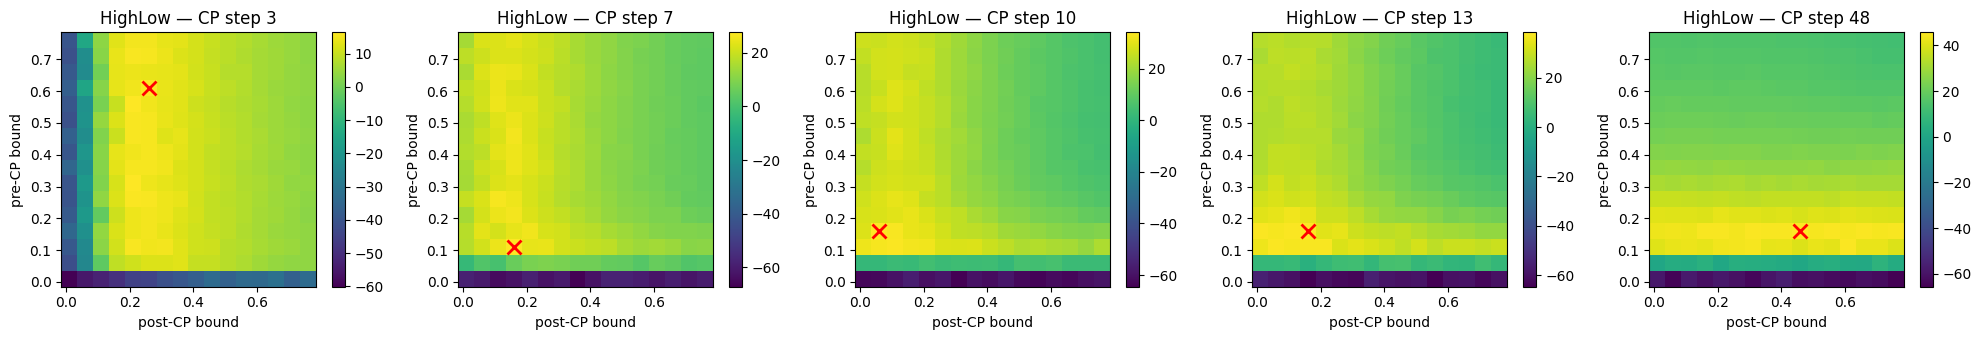

In [7]:
cp_rr_lh = None   # LowHigh: g_means = [lo, hi]
cp_rr_hl = None   # HighLow: g_means = [hi, lo]

if COMPUTE_CP:
    print(f'Computing CP RR matrix (LowHigh, {len(CP_STEPS_LH)} CP steps × 16×16 bounds)...')
    cp_rr_lh = get_rr_matrix(
        bounds=BOUNDS, num_reps=NUM_REPS,
        g_means=G_MEANS,            # [lo, hi]: SNR starts low, switches to high
        g_std=G_STD,
        blocks=CP_STEPS_LH, block_type='CP',
        rng=rng,
    )
    print(f'LowHigh CP RR matrix shape: {cp_rr_lh.shape}')

    print(f'Computing CP RR matrix (HighLow, {len(CP_STEPS_HL)} CP steps × 16×16 bounds)...')
    cp_rr_hl = get_rr_matrix(
        bounds=BOUNDS, num_reps=NUM_REPS,
        g_means=G_MEANS[::-1],      # [hi, lo]: SNR starts high, switches to low
        g_std=G_STD,
        blocks=CP_STEPS_HL, block_type='CP',
        rng=rng,
    )
    print(f'HighLow CP RR matrix shape: {cp_rr_hl.shape}')

    # ── Plot heatmaps: 5 evenly-spaced CP steps from each condition ──
    n_show    = 5
    b0, b1_v  = BOUNDS[0], BOUNDS[-1]

    for mat, steps, title in [(cp_rr_lh, CP_STEPS_LH, 'LowHigh'),
                               (cp_rr_hl, CP_STEPS_HL, 'HighLow')]:
        show_idxs = np.round(np.linspace(0, len(steps) - 1, min(n_show, len(steps)))).astype(int)
        n_cols    = len(show_idxs)
        fig, axs  = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5))
        if n_cols == 1:
            axs = [axs]
        for ai, ci in enumerate(show_idxs):
            ax  = axs[ai]
            slc = mat[:, :, ci]
            im  = ax.imshow(
                slc, origin='lower',
                extent=[b0 - 0.025, b1_v + 0.025, b0 - 0.025, b1_v + 0.025],
                aspect='auto', cmap='viridis',
            )
            plt.colorbar(im, ax=ax)
            opt_pre, opt_post = np.unravel_index(slc.argmax(), slc.shape)
            ax.plot(BOUNDS[opt_post], BOUNDS[opt_pre],
                    'rx', markersize=10, markeredgewidth=2)
            ax.set_xlabel('post-CP bound')
            ax.set_ylabel('pre-CP bound')
            ax.set_title(f'{title} — CP step {steps[ci]}')
        plt.tight_layout()
        plt.show()

## Save matrices for Figure 06

Saves the CP matrices to `RRMats.mat` in the format expected by
`Figure06_cpSummary.ipynb`:

- **`pmats`**: 1 × 2 MATLAB cell array where `pmats{1}` = LowHigh matrix
  `(n_bounds, n_bounds, n_lh_steps)` and `pmats{2}` = HighLow matrix
  `(n_bounds, n_bounds, n_hl_steps)`.
- **`bounds`**: the bound grid used.
- **`cp_steps_lh`**: CP step positions for LowHigh (3rd axis of `pmats{1}`).
- **`cp_steps_hl`**: CP step positions for HighLow (3rd axis of `pmats{2}`).
- **`g_means`**: generative means (LowHigh convention: `[lo, hi]`).

The two conditions store separate `cp_steps` arrays because they have
different sets of unique CP steps in the real data.

**Note**: Only saves if `COMPUTE_CP = True` and both matrices are available.

In [8]:
import os

if cp_rr_lh is not None and cp_rr_hl is not None:
    os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)

    # MATLAB cell array: pmats{1} = LowHigh, pmats{2} = HighLow
    pmats       = np.empty((1, 2), dtype=object)
    pmats[0, 0] = cp_rr_lh
    pmats[0, 1] = cp_rr_hl

    scipy.io.savemat(OUTPUT_FILE, {
        'pmats'       : pmats,
        'bounds'      : BOUNDS,
        'cp_steps_lh' : np.array(CP_STEPS_LH),
        'cp_steps_hl' : np.array(CP_STEPS_HL),
        'g_means'     : np.array(G_MEANS),
        'g_std'       : G_STD,
        'num_reps'    : NUM_REPS,
    })
    print(f'Saved {OUTPUT_FILE}')
    print(f'  pmats[0,0] (LowHigh) shape: {cp_rr_lh.shape}  '
          f'CP steps: {CP_STEPS_LH[:3]}...{CP_STEPS_LH[-3:]}')
    print(f'  pmats[0,1] (HighLow) shape: {cp_rr_hl.shape}  '
          f'CP steps: {CP_STEPS_HL[:3]}...{CP_STEPS_HL[-3:]}')
else:
    print('CP matrices not computed — set COMPUTE_CP = True to generate and save.')

if ol_rr is not None:
    scipy.io.savemat(OUTPUT_FILE_OL, {
        'rr_matrix': ol_rr,
        'bounds'   : BOUNDS,
        'blocks'   : np.array(OL_BLOCKS),
        'g_means'  : np.array(G_MEANS),
    })
    print(f'Saved {OUTPUT_FILE_OL}')

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Data/Processed/Python/RRMats.mat
  pmats[0,0] (LowHigh) shape: (16, 16, 21)  CP steps: [3, 4, 5]...[26, 29, 37]
  pmats[0,1] (HighLow) shape: (16, 16, 15)  CP steps: [3, 4, 5]...[15, 16, 48]
Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Data/Processed/Python/RRMats_OL.mat
